## Support Vector Machine (SVM)

El algoritmo Support Vector Machine (SVM) es un modelo de clasificación que busca encontrar el hiperplano que mejor separa las clases en un espacio multidimensional. En el caso de la regresión, también puede ser usado para predecir valores continuos.

### Objetivo
Clasificar las observaciones en una de las dos clases (en problemas binarios) o en múltiples clases (en problemas multiclase), maximizando el margen entre las clases.

### Conceptos Claves:
- **Hiperplano**: Es el límite que separa las clases en el espacio de características. En un problema binario, se busca el hiperplano que maximice la distancia entre las observaciones de ambas clases.
- **Margen**: Es la distancia entre el hiperplano y las observaciones más cercanas de cada clase (los vectores de soporte). Un margen más amplio indica un mejor modelo.
- **Vectores de soporte**: Son las observaciones más cercanas al hiperplano y son cruciales para la definición del mismo.
- **Kernel**: Función matemática que permite transformar los datos no lineales en un espacio de mayor dimensión donde se pueda encontrar un hiperplano lineal de separación. Los tipos más comunes son el kernel lineal, polinómico y radial (RBF).
- **Función de decisión**: La función que se utiliza para predecir la clase de una observación, dependiendo de la distancia al hiperplano.

### Variables requeridas
Se pueden utilizar variables continuas y categóricas (codificadas), y es recomendable escalar las características para garantizar que el SVM funcione correctamente, especialmente con kernels no lineales.

### Algoritmo
1. **Preparación de los datos**: Codificar variables categóricas y escalar las variables continuas si es necesario.
2. **Ajuste del modelo**: Buscar el hiperplano que maximice el margen entre las clases utilizando la optimización basada en el margen y el término de regularización (C).
3. **Predicción**: Calcular la clase de una observación en base a su posición respecto al hiperplano. Si el valor es positivo, pertenece a una clase; si es negativo, a la otra.
4. **Ajuste de parámetros** (opcional): Ajustar el parámetro de regularización (C) y la elección del kernel para optimizar el rendimiento del modelo.

### Evaluación
Se puede evaluar el modelo utilizando métricas como precisión, exactitud, sensibilidad, especificidad, y mediante una matriz de confusión. También se utiliza el área bajo la curva ROC (AUC-ROC) para evaluar el rendimiento en problemas de clasificación binaria.


In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el dataset
data = load_breast_cancer()

# Crear un DataFrame
df_breast_cancer = pd.DataFrame(data.data, columns=data.feature_names)

# Agregar la columna de la variable objetivo (target)
df_breast_cancer['target'] = data.target

# Mostrar las primeras filas del dataset
df_breast_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df_breast_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
from sklearn.preprocessing import StandardScaler

# Separar las características y la variable objetivo
X = df_breast_cancer.drop('target', axis=1)
y = df_breast_cancer['target']

# Normalización de las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir a DataFrame para mantener la estructura
X_scaled_df = pd.DataFrame(X_scaled, columns=data.feature_names)

# Mostrar las primeras filas de los datos normalizados
X_scaled_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [5]:
from sklearn.model_selection import train_test_split

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Verificar las dimensiones de los conjuntos
print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)

Tamaño del conjunto de entrenamiento: (398, 30)
Tamaño del conjunto de prueba: (171, 30)


c:\Users\csolis\AppData\Local\anaconda3\envs\mi_entorno\lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


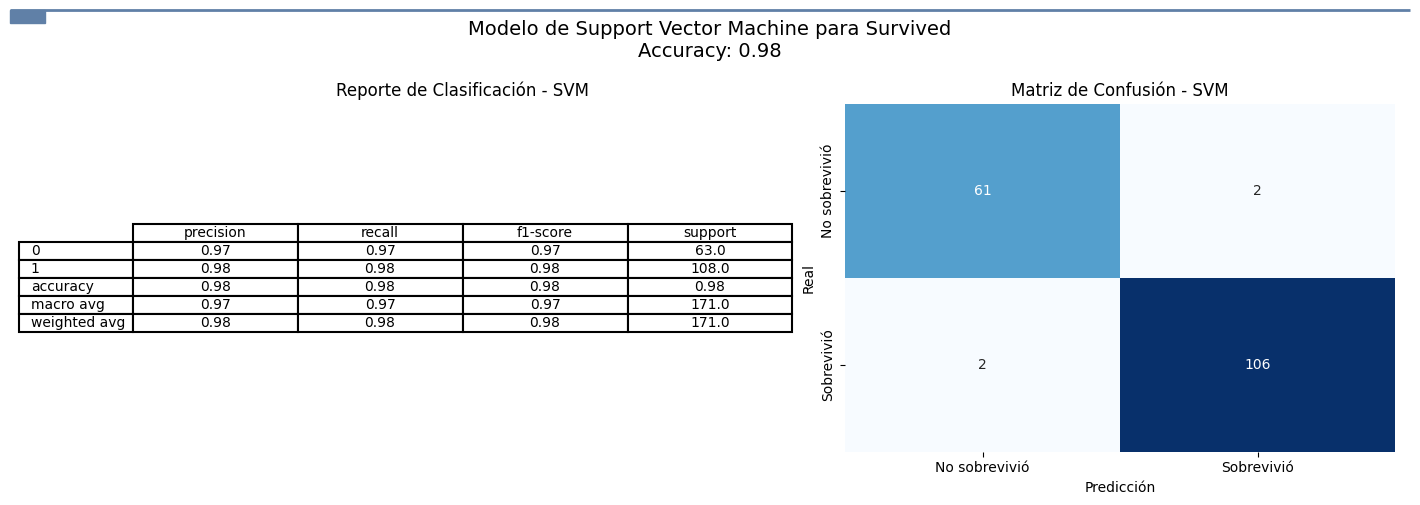

In [6]:
from sklearn.svm import SVC
from matplotlib import lines
from matplotlib import patches
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

# Crear y entrenar el modelo SVM
svm_model = SVC(kernel='linear', max_iter=1000)  # Usando kernel lineal
svm_model.fit(X_train, y_train)

# Predicción y evaluación
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
report_df_svm = pd.DataFrame(classification_report(y_test, y_pred_svm, output_dict=True)).transpose().round(2)

# Resultados SVM
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Modelo de Support Vector Machine para Survived\nAccuracy: {accuracy_svm:.2f}', fontsize=14)
fig.add_artist(lines.Line2D([0, 1], [1, 1], lw=2, color='#6080A7', solid_capstyle="butt"))
fig.add_artist(patches.Rectangle((0, 0.975), 0.025, 0.025, color='#6080A7'))

# Reporte de clasificación
ax[0].set_title("Reporte de Clasificación - SVM", fontsize=12)
ax[0].axis('off')  
table_svm = ax[0].table(cellText=report_df_svm.values, colLabels=report_df_svm.columns, rowLabels=report_df_svm.index, cellLoc='center', loc='center', edges='BRTL')
table_svm.auto_set_font_size(False)
table_svm.set_fontsize(10)
table_svm.scale(1.2, 1.2)
for key, cell in table_svm.get_celld().items():
    cell.set_linewidth(1.5)

# Matriz de confusión
sns.heatmap(conf_matrix_svm, annot=True, fmt="d", cmap="Blues", ax=ax[1], cbar=False,
            xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
ax[1].set_title("Matriz de Confusión - SVM", fontsize=12)
ax[1].set_xlabel("Predicción")
ax[1].set_ylabel("Real")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

# Asegúrate de que X es un DataFrame (si no lo es, convertirlo)
X = df_breast_cancer.drop('target', axis=1)
y = df_breast_cancer['target']

# Si X no es un DataFrame, conviértelo a uno
if isinstance(X, np.ndarray):
    X = pd.DataFrame(X)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Definir diferentes kernels
kernels = ['linear', 'poly', 'rbf']

# Crear la figura para las subgráficas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Visualizar para cada tipo de kernel
for i, kernel in enumerate(kernels):
    # Ajustar el modelo SVM con el kernel correspondiente
    svm_model = SVC(kernel=kernel, gamma='auto')  # Ajuste de gamma=auto para facilitar la visualización
    svm_model.fit(X_train, y_train)

    # Crear un grid para la visualización de la decisión (solo para 2 características)
    if X.shape[1] == 2:  # Solo si tienes exactamente 2 características para la visualización
        h = .02  # Resolución de la malla
        x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
        y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

        # Predecir las etiquetas para cada punto en la malla
        Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Dibujar los contornos de la decisión y los puntos de datos
        ax = axes[i]
        ax.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
        ax.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, edgecolors='k', marker='o', cmap='coolwarm', s=60)
        ax.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test, edgecolors='k', marker='x', cmap='coolwarm', s=100)

        ax.set_title(f'SVM con kernel {kernel}')
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# Crear y entrenar el modelo SVM con el kernel lineal para evaluación
svm_model = SVC(kernel='linear', max_iter=1000)
svm_model.fit(X_train, y_train)

# Predicción y evaluación
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
report_df_svm = pd.DataFrame(classification_report(y_test, y_pred_svm, output_dict=True)).transpose().round(2)

# Resultados SVM
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Modelo de Support Vector Machine\nAccuracy: {accuracy_svm:.2f}', fontsize=14)

# Reporte de clasificación
ax[0].set_title("Reporte de Clasificación - SVM", fontsize=12)
ax[0].axis('off')  
table_svm = ax[0].table(cellText=report_df_svm.values, colLabels=report_df_svm.columns, rowLabels=report_df_svm.index, cellLoc='center', loc='center', edges='BRTL')
table_svm.auto_set_font_size(False)
table_svm.set_fontsize(10)
table_svm.scale(1.2, 1.2)
for key, cell in table_svm.get_celld().items():
    cell.set_linewidth(1.5)

# Matriz de confusión
sns.heatmap(conf_matrix_svm, annot=True, fmt="d", cmap="Blues", ax=ax[1], cbar=False,
            xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'])
ax[1].set_title("Matriz de Confusión - SVM", fontsize=12)
ax[1].set_xlabel("Predicción")
ax[1].set_ylabel("Real")

plt.tight_layout()
plt.show()
